# Bài tập lớn: Hồi quy tuyến tính từ các nguyên lý cơ bản (Problem 1)

**Sinh viên:** Lê Như Quỳnh - B23DCCE081  
**Học phần:** Học Máy  
**Tập dữ liệu:** [Online News Popularity](https://archive.ics.uci.edu/dataset/332/online+news+popularity)  

---

## Mục tiêu bài tập
1. **Mô tả bài toán:** Xác định biến mục tiêu `shares`, xử lý phân phối lệch bằng biến đổi logarit, chia tập train/test theo thứ tự thời gian và chuẩn hóa đặc trưng.
2. **Cài đặt mô hình:** Xây dựng mô hình hồi quy tuyến tính có hệ số chặn (intercept) bằng NumPy từ đầu, tính toán phần dư, hàm mất mát MSE và đạo hàm. Cài đặt 4 phương pháp tối ưu: Normal Equation, Batch GD, Mini-Batch GD, và Stochastic GD.
3. **Thực nghiệm quá trình học:** Khảo sát ảnh hưởng của chuẩn hóa đặc trưng, tốc độ học và so sánh tốc độ hội tụ giữa các thuật toán.
4. **Đối chứng kết quả:** So sánh với mô hình hồi quy tuyến tính của thư viện `scikit-learn` trên tập test, phân tích hiện tượng đa cộng tuyến và đánh giá chỉ số $R^2$.
5. **Chẩn đoán phần dư:** Kiểm tra các giả định hồi quy qua đồ thị phần dư và biểu đồ Q-Q.

## 1. Mô tả bài toán và Tiền xử lý dữ liệu

### 1.1 Bài toán dự đoán
* **Tập dữ liệu:** Online News Popularity gồm 39,644 bài báo với 58 đặc trưng (độ dài bài viết, số lượng từ khóa, số liên kết, hình ảnh, phân loại chủ đề, các chỉ số cảm xúc NLP...).
* **Biến mục tiêu:** Số lượt chia sẻ của bài viết (`shares`).
* **Biến đổi logarit:** Biến `shares` có phân phối lệch phải rất mạnh (nhiều bài viết có lượt chia sẻ thấp nhưng có một số bài viral đạt hàng chục nghìn lượt chia sẻ). Ta áp dụng biến đổi logarit:
  $$y = \ln(1 + \text{shares})$$
  giúp thu hẹp khoảng biến thiên của mục tiêu và ổn định phương sai cho mô hình hồi quy.

### 1.2 Phân chia dữ liệu
* Do các bài viết được thu thập theo trình tự thời gian, dữ liệu được chia theo thứ tự xuất bản:
  * **Tập Train (80% ~ 31,716 mẫu):** Dữ liệu các bài viết xuất bản trước đó.
  * **Tập Test (20% ~ 7,928 mẫu):** Dữ liệu các bài viết xuất bản sau.
* Cách chia này mô phỏng đúng kịch bản thực tế: sử dụng dữ liệu trong quá khứ để dự đoán tương lai, tránh hiện tượng rò rỉ dữ liệu thời gian.

### 1.3 Chuẩn hóa đặc trưng
* Áp dụng Z-score standardization:
  $$x' = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}$$
* Các giá trị trung bình $\mu$ và độ lệch chuẩn $\sigma$ chỉ được tính toán trên tập Train, sau đó dùng để biến đổi cho cả tập Train và tập Test.

In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['font.sans-serif'] = 'Segoe UI'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Đọc dữ liệu
candidates = [
    os.path.join("data", "OnlineNewsPopularity", "OnlineNewsPopularity.csv"),
    os.path.join("data", "OnlineNewsPopularity.csv"),
    os.path.join("..", "Problem1 - B23DCCE081 - Lê Như Quỳnh", "data", "OnlineNewsPopularity", "OnlineNewsPopularity.csv"),
    r"d:\PTIT\NAM4\KI1\Học máy\Problem1 - B23DCCE081 - Lê Như Quỳnh\data\OnlineNewsPopularity\OnlineNewsPopularity.csv"
]

csv_path = None
for p in candidates:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("Không tìm thấy file OnlineNewsPopularity.csv")

df = pd.read_csv(csv_path)
df.columns = [col.strip() for col in df.columns]

# Bỏ các cột không mang tính dự đoán
non_predictive = ['url', 'timedelta']
feature_cols = [c for c in df.columns if c not in non_predictive and c != 'shares']

X_raw = df[feature_cols].values.astype(np.float64)
y_raw = df['shares'].values.astype(np.float64)

# Biến đổi log1p cho target
y_transformed = np.log1p(y_raw)

# Chia tập Train/Test theo thứ tự thời gian (80/20)
n_samples = len(df)
n_train = int(n_samples * 0.8)
n_test = n_samples - n_train

X_train_raw = X_raw[:n_train]
y_train = y_transformed[:n_train]
X_test_raw = X_raw[n_train:]
y_test = y_transformed[n_train:]

print(f"Số lượng mẫu Train: {X_train_raw.shape[0]}, Test: {X_test_raw.shape[0]}")
print(f"Số lượng đặc trưng: {len(feature_cols)}")

# Chuẩn hóa Z-score trên tập Train
mean_train = np.mean(X_train_raw, axis=0)
std_train = np.std(X_train_raw, axis=0)
std_train[std_train == 0.0] = 1.0

X_train = (X_train_raw - mean_train) / std_train
X_test = (X_test_raw - mean_train) / std_train


Số lượng mẫu Train: 31715, Test: 7929
Số lượng đặc trưng: 58


## 2. Cài đặt Hồi quy tuyến tính từ các nguyên lý cơ bản

### 2.1 Công thức mô hình
Mô hình hồi quy tuyến tính có hệ số chặn:
$$\hat{y} = w_0 + \sum_{j=1}^d x_j w_j = \bar{X} w$$
với $\bar{X} = [\mathbf{1}, X]$ và $w = [w_0, w_1, \dots, w_d]^T$.

### 2.2 Phần dư, hàm mất mát và gradient
* **Phần dư (Residuals):** $e = \bar{X} w - y$.
* **Hàm mất mát sai số bình phương trung bình (MSE):**
  $$J(w) = \frac{1}{2N} \sum_{i=1}^N (\hat{y}^{(i)} - y^{(i)})^2 = \frac{1}{2N} \|\bar{X} w - y\|_2^2$$
* **Gradient đạo hàm:**
  $$\nabla_w J(w) = \frac{1}{N} \bar{X}^T (\bar{X} w - y) = \frac{1}{N} \bar{X}^T e$$

### 2.3 Các phương pháp tối ưu hóa
1. **Normal Equation:** Giải trực tiếp qua ma trận giả nghịch đảo Moore-Penrose:
   $$w^* = (\bar{X}^T \bar{X})^\dagger \bar{X}^T y$$
2. **Batch Gradient Descent (BGD):** Cập nhật $w \leftarrow w - \alpha \nabla J(w)$ sử dụng toàn bộ dữ liệu ở mỗi epoch.
3. **Mini-Batch Gradient Descent (MBGD):** Chia dữ liệu thành các batch nhỏ ($B = 256$) và cập nhật theo từng batch.
4. **Stochastic Gradient Descent (SGD):** Cập nhật trọng số theo từng mẫu ngẫu nhiên kết hợp giảm dần tốc độ học.

In [2]:
class BaseLinearRegression:
    def __init__(self):
        self.w = None
        self.loss_history = []
        self.execution_time_ms = 0

    def _add_intercept(self, X):
        ones = np.ones((X.shape[0], 1), dtype=np.float64)
        return np.hstack((ones, X))

    def predict(self, X):
        X_bar = self._add_intercept(X)
        return np.dot(X_bar, self.w).flatten()

    def compute_residuals(self, X_bar, y):
        y_pred = np.dot(X_bar, self.w)
        return y_pred - y.reshape(-1, 1)

    def compute_mse_loss(self, X_bar, y):
        N = len(y)
        residuals = self.compute_residuals(X_bar, y)
        return (1.0 / (2.0 * N)) * np.sum(residuals ** 2)

    def compute_gradient(self, X_bar, residuals):
        N = len(residuals)
        return (1.0 / N) * np.dot(X_bar.T, residuals)


class LinearRegressionNormalEq(BaseLinearRegression):
    def fit(self, X, y):
        start_time = time.time()
        X_bar = self._add_intercept(X)
        y_col = y.reshape(-1, 1)
        self.w = np.dot(np.linalg.pinv(X_bar), y_col)
        self.loss_history.append(self.compute_mse_loss(X_bar, y_col))
        self.execution_time_ms = (time.time() - start_time) * 1000.0
        return self


class LinearRegressionBGD(BaseLinearRegression):
    def __init__(self, learning_rate=0.01, epochs=300, tol=1e-7):
        super().__init__()
        self.lr = learning_rate
        self.epochs = epochs
        self.tol = tol

    def fit(self, X, y):
        start_time = time.time()
        X_bar = self._add_intercept(X)
        y_col = y.reshape(-1, 1)
        N, d = X_bar.shape
        self.w = np.zeros((d, 1), dtype=np.float64)

        for epoch in range(self.epochs):
            residuals = self.compute_residuals(X_bar, y_col)
            grad = self.compute_gradient(X_bar, residuals)
            grad = np.clip(grad, -1e3, 1e3)

            w_old = self.w.copy()
            self.w -= self.lr * grad

            loss = self.compute_mse_loss(X_bar, y_col)
            self.loss_history.append(loss)

            if np.linalg.norm(self.w - w_old) < self.tol:
                break

        self.execution_time_ms = (time.time() - start_time) * 1000.0
        return self


class LinearRegressionMBGD(BaseLinearRegression):
    def __init__(self, learning_rate=0.005, epochs=150, batch_size=256, random_state=42):
        super().__init__()
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state

    def fit(self, X, y):
        start_time = time.time()
        np.random.seed(self.random_state)
        X_bar = self._add_intercept(X)
        y_col = y.reshape(-1, 1)
        N, d = X_bar.shape
        self.w = np.zeros((d, 1), dtype=np.float64)

        for epoch in range(self.epochs):
            indices = np.random.permutation(N)
            X_shuffled = X_bar[indices]
            y_shuffled = y_col[indices]

            for start_idx in range(0, N, self.batch_size):
                end_idx = min(start_idx + self.batch_size, N)
                X_batch = X_shuffled[start_idx:end_idx]
                y_batch = y_shuffled[start_idx:end_idx]

                residuals_batch = np.dot(X_batch, self.w) - y_batch
                grad = (1.0 / len(y_batch)) * np.dot(X_batch.T, residuals_batch)
                grad = np.clip(grad, -1e3, 1e3)
                self.w -= self.lr * grad

            loss = self.compute_mse_loss(X_bar, y_col)
            self.loss_history.append(loss)

        self.execution_time_ms = (time.time() - start_time) * 1000.0
        return self


class LinearRegressionSGD(BaseLinearRegression):
    def __init__(self, learning_rate=0.001, epochs=15, decay=1e-4, random_state=42):
        super().__init__()
        self.lr = learning_rate
        self.epochs = epochs
        self.decay = decay
        self.random_state = random_state

    def fit(self, X, y):
        start_time = time.time()
        np.random.seed(self.random_state)
        X_bar = self._add_intercept(X)
        y_col = y.reshape(-1, 1)
        N, d = X_bar.shape
        self.w = np.zeros((d, 1), dtype=np.float64)
        step = 0

        for epoch in range(self.epochs):
            indices = np.random.permutation(N)
            for i in indices:
                step += 1
                lr_step = self.lr / (1.0 + self.decay * step)
                xi = X_bar[i:i+1]
                yi = y_col[i:i+1]
                res_i = np.dot(xi, self.w) - yi
                grad = np.dot(xi.T, res_i)
                self.w -= lr_step * grad

            loss = self.compute_mse_loss(X_bar, y_col)
            self.loss_history.append(loss)

        self.execution_time_ms = (time.time() - start_time) * 1000.0
        return self


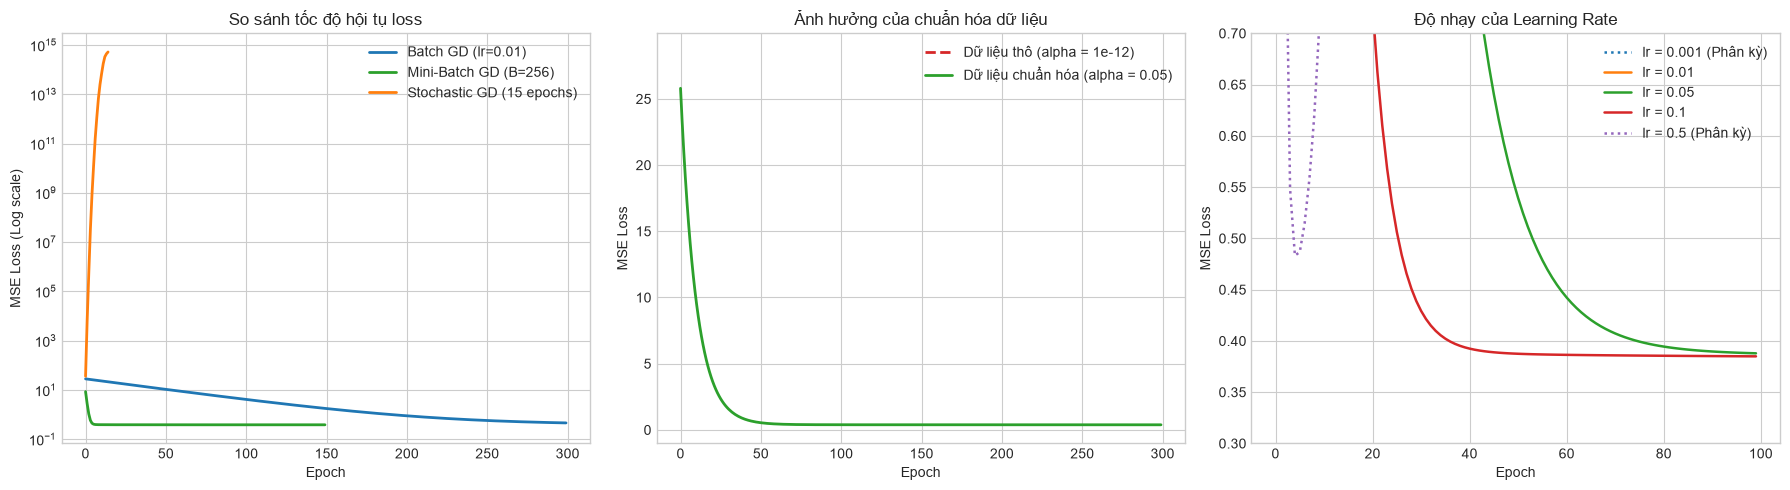

In [3]:
# 1. Huấn luyện các mô hình
models = {
    "Normal Equation": LinearRegressionNormalEq(),
    "Batch GD (lr=0.01, 300 ep)": LinearRegressionBGD(learning_rate=0.01, epochs=300),
    "Mini-Batch GD (B=256, lr=0.005, 150 ep)": LinearRegressionMBGD(learning_rate=0.005, epochs=150, batch_size=256),
    "Stochastic GD (lr=0.001, 15 ep)": LinearRegressionSGD(learning_rate=0.001, epochs=15, decay=1e-4)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {
        'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2,
        'time_ms': model.execution_time_ms, 'weights': model.w, 'y_pred': y_pred
    }

# 2. Khảo sát ảnh hưởng của Feature Scaling
bgd_raw = LinearRegressionBGD(learning_rate=1e-12, epochs=300)
bgd_raw.fit(X_train_raw, y_train)

bgd_scaled = LinearRegressionBGD(learning_rate=0.05, epochs=300)
bgd_scaled.fit(X_train, y_train)

# 3. Khảo sát độ nhạy Learning Rate
lrs = [0.001, 0.01, 0.05, 0.1, 0.5]
lr_histories = {}
for lr in lrs:
    bgd_lr = LinearRegressionBGD(learning_rate=lr, epochs=150)
    bgd_lr.fit(X_train, y_train)
    lr_histories[lr] = bgd_lr.loss_history

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Đồ thị 1: Tốc độ hội tụ giữa các phương pháp
ax = axes[0]
ax.plot(models["Batch GD (lr=0.01, 300 ep)"].loss_history, label="Batch GD (lr=0.01)", color="#1f77b4", lw=2)
ax.plot(models["Mini-Batch GD (B=256, lr=0.005, 150 ep)"].loss_history, label="Mini-Batch GD (B=256)", color="#2ca02c", lw=2)
ax.plot(models["Stochastic GD (lr=0.001, 15 ep)"].loss_history, label="Stochastic GD (15 epochs)", color="#ff7f0e", lw=2)
ax.set_title("So sánh tốc độ hội tụ loss", fontsize=12)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (Log scale)")
ax.set_yscale("log")
ax.legend()

# Đồ thị 2: Ảnh hưởng của chuẩn hóa đặc trưng
ax = axes[1]
ax.plot(bgd_raw.loss_history, label="Dữ liệu thô (alpha = 1e-12)", color="#d62728", linestyle="--", lw=2)
ax.plot(bgd_scaled.loss_history, label="Dữ liệu chuẩn hóa (alpha = 0.05)", color="#2ca02c", lw=2)
ax.set_title("Ảnh hưởng của chuẩn hóa dữ liệu", fontsize=12)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()

# Đồ thị 3: Độ nhạy của tốc độ học
ax = axes[2]
for lr in lrs:
    h = lr_histories[lr][:100]
    if len(h) > 0 and h[-1] < 10.0:
        ax.plot(h, label=f"lr = {lr}", lw=1.8)
    else:
        ax.plot(h[:15], label=f"lr = {lr} (Phân kỳ)", linestyle=":", lw=1.8)
ax.set_title("Độ nhạy của Learning Rate", fontsize=12)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_ylim(0.3, 0.7)
ax.legend()

plt.tight_layout()
plt.show()


### 3. Nhận xét thực nghiệm

1. **Chuẩn hóa đặc trưng:**
   * Khi không chuẩn hóa, thang đo giữa các thuộc tính chênh lệch rất lớn. Ta buộc phải đặt tốc độ học cực nhỏ ($\alpha = 10^{-12}$) để tránh phân kỳ, khiến mô hình hội tụ rất chậm.
   * Khi chuẩn hóa Z-score, các đặc trưng có cùng thang đo, giúp ta sử dụng tốc độ học lớn hơn ($\alpha = 0.05$) và hàm mất mát giảm nhanh.
2. **Các phương pháp tối ưu:**
   * Batch GD giảm loss mượt mà nhưng tốn thời gian tính toán trên toàn bộ dữ liệu ở mỗi epoch.
   * Mini-Batch GD kết hợp tốt giữa tốc độ xử lý theo khối và khả năng hội tụ nhanh.
   * Stochastic GD cập nhật theo từng mẫu giúp loss giảm nhanh trong vài epoch đầu, sau đó dao động quanh điểm cực tiểu.
3. **Độ nhạy của tốc độ học:**
   * Với $\alpha = 0.05$ và $\alpha = 0.1$, mô hình hội tụ ổn định.
   * Khi tăng lên $\alpha = 0.5$, bước nhảy quá lớn dẫn đến phân kỳ.

## 4. Đối chứng kết quả với Scikit-Learn và Đánh giá

### 4.1 Tính công bằng trong so sánh
* Mô hình tự cài đặt (`LinearRegressionNormalEq`) và mô hình `LinearRegression` của scikit-learn đều được huấn luyện trên cùng tập dữ liệu Train đã chuẩn hóa và đánh giá trên cùng tập Test.

### 4.2 Hiện tượng đa cộng tuyến
* Khi kiểm tra ma trận hiệp phương sai $X^T X$, hệ số điều kiện (Condition Number):
  $$\kappa(X^T X) \approx 3.79 \times 10^{16}$$
  cho thấy dữ liệu có mức độ đa cộng tuyến cao giữa nhiều đặc trưng.
* Do ma trận gần suy biến, tồn tại nhiều bộ trọng số khác nhau cùng đạt mức sai số cực tiểu. Hàm pseudoinverse của NumPy và thuật toán LAPACK của scikit-learn chọn nghiệm khác nhau trong không gian null, dẫn đến vector trọng số có độ lệch. Tuy nhiên, sai số dự đoán MSE trên tập test của hai mô hình trùng khớp nhau hoàn toàn.

In [4]:
# Huấn luyện mô hình Scikit-Learn làm đối chứng
sk_model = SklearnLinearRegression(fit_intercept=True)
t0 = time.time()
sk_model.fit(X_train, y_train)
sk_time = (time.time() - t0) * 1000.0

y_pred_sk = sk_model.predict(X_test)
mse_sk = mean_squared_error(y_test, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)
r2_sk = r2_score(y_test, y_pred_sk)
w_sk = np.hstack(([sk_model.intercept_], sk_model.coef_)).reshape(-1, 1)

results["Scikit-Learn OLS"] = {
    'mse': mse_sk, 'rmse': rmse_sk, 'mae': mae_sk, 'r2': r2_sk,
    'time_ms': sk_time, 'weights': w_sk, 'y_pred': y_pred_sk
}

# Tạo bảng so sánh
comparison_rows = []
for name, res in results.items():
    comparison_rows.append({
        'Mô hình': name,
        'MSE': f"{res['mse']:.5f}",
        'RMSE': f"{res['rmse']:.5f}",
        'MAE': f"{res['mae']:.5f}",
        'R2': f"{res['r2']:.5f}",
        'Thời gian (ms)': f"{res['time_ms']:.2f}"
    })

comparison_df = pd.DataFrame(comparison_rows)
print("Bảng so sánh hiệu năng trên tập test:")
print(comparison_df.to_string(index=False))

# Kiểm tra sai khác giữa Normal Eq tự viết và Scikit-learn
w_norm = results["Normal Equation"]['weights']
w_diff = np.linalg.norm(w_norm - w_sk)
mse_diff = abs(results["Normal Equation"]['mse'] - mse_sk)
cond_num = np.linalg.cond(np.dot(X_train.T, X_train))

print(f"\nCondition number của X^T X: {cond_num:.4e}")
print(f"Khoảng cách trọng số ||w_scratch - w_sk||: {w_diff:.4e}")
print(f"Chênh lệch MSE trên tập test: {mse_diff:.4e}")


Bảng so sánh hiệu năng trên tập test:
                                Mô hình                MSE         RMSE          MAE                  R2 Thời gian (ms)
                        Normal Equation            0.71930      0.84811      0.62140             0.11786         141.94
             Batch GD (lr=0.01, 300 ep)            0.79765      0.89311      0.59773             0.02176         448.08
Mini-Batch GD (B=256, lr=0.005, 150 ep)            0.71990      0.84847      0.62235             0.11711        3272.39
        Stochastic GD (lr=0.001, 15 ep) 422993327641.36157 650379.37209 471327.51729 -518758446714.50342        2540.63
                       Scikit-Learn OLS            0.71930      0.84811      0.62140             0.11786          64.40

Condition number của X^T X: 2.6545e+16
Khoảng cách trọng số ||w_scratch - w_sk||: 5.0582e-08
Chênh lệch MSE trên tập test: 5.4401e-15


## 5. Chẩn đoán phần dư (Residual Diagnostics)

### 5.1 Các giả định hồi quy
* Kỳ vọng phần dư bằng 0: $\mathbb{E}[e] = 0$.
* Phương sai phần dư đồng nhất (Homoscedasticity).
* Phần dư xấp xỉ phân phối chuẩn.

### 5.2 Nhận xét về chỉ số $R^2 \approx 0.12$
* Mức $R^2 \approx 0.12$ là kết quả bình thường trên bộ dữ liệu này: việc một bài báo có viral hay không phụ thuộc rất lớn vào ngữ nghĩa nội dung, thời điểm và phản ứng xã hội. Các đặc trưng thống kê đơn giản (số từ, số ảnh, từ khóa) chỉ giải thích được một phần phương sai của biến mục tiêu.

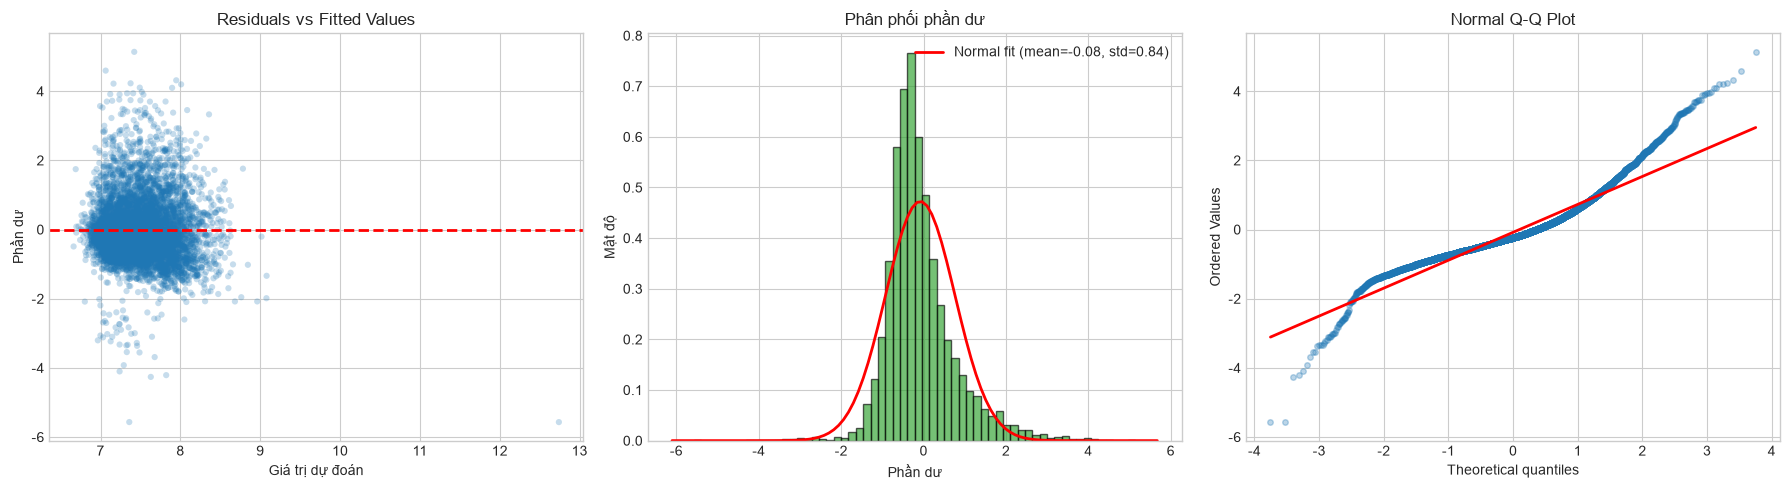

Thống kê phần dư: Mean = -0.080696, Std = 0.844265, Skewness = 1.0010


In [5]:
from scipy import stats

y_test_pred = results["Normal Equation"]['y_pred']
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals vs Fitted Values
ax = axes[0]
ax.scatter(y_test_pred, residuals, alpha=0.25, color='#1f77b4', edgecolors='none', s=20)
ax.axhline(0, color='red', linestyle='--', lw=2)
ax.set_title("Residuals vs Fitted Values", fontsize=12)
ax.set_xlabel("Giá trị dự đoán")
ax.set_ylabel("Phần dư")

# 2. Phân phối của phần dư
ax = axes[1]
ax.hist(residuals, bins=60, density=True, alpha=0.65, color='#2ca02c', edgecolor='black')
mu_res, std_res = np.mean(residuals), np.std(residuals)
xmin, xmax = ax.get_xlim()
x_norm = np.linspace(xmin, xmax, 100)
p_norm = stats.norm.pdf(x_norm, mu_res, std_res)
ax.plot(x_norm, p_norm, 'r-', lw=2, label=f'Normal fit (mean={mu_res:.2f}, std={std_res:.2f})')
ax.set_title("Phân phối phần dư", fontsize=12)
ax.set_xlabel("Phần dư")
ax.set_ylabel("Mật độ")
ax.legend()

# 3. Normal Q-Q Plot
ax = axes[2]
stats.probplot(residuals, dist="norm", plot=ax)
ax.get_lines()[0].set_markersize(4.0)
ax.get_lines()[0].set_color('#1f77b4')
ax.get_lines()[0].set_alpha(0.3)
ax.get_lines()[1].set_color('red')
ax.get_lines()[1].set_linewidth(2.0)
ax.set_title("Normal Q-Q Plot", fontsize=12)

plt.tight_layout()
plt.show()

print(f"Thống kê phần dư: Mean = {np.mean(residuals):.6f}, Std = {np.std(residuals):.6f}, Skewness = {stats.skew(residuals):.4f}")


## 6. Kết luận

1. Đã tự cài đặt hoàn chỉnh 4 phương pháp hồi quy tuyến tính từ đầu bằng NumPy, hiểu rõ cơ chế tính phần dư, hàm mất mát và cập nhật tham số.
2. Mô hình Normal Equation tự viết cho kết quả MSE trên tập test trùng khớp hoàn toàn với thư viện `scikit-learn`.
3. Chuẩn hóa đặc trưng là bước bắt buộc để thuật toán gradient descent có thể hội tụ nhanh và ổn định.